In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,KFold,cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler,OrdinalEncoder
from sklearn.metrics import (accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,roc_auc_score,roc_curve)
from sklearn.model_selection import GridSearchCV
import joblib
from matplotlib import style
style.use('seaborn-v0_8')


In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,Row,Id,Surname,Score,Nationality,Gender,Age,Tenure,Balance,Products,Card,Active,Salary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Row          10000 non-null  int64  
 1   Id           10000 non-null  int64  
 2   Surname      10000 non-null  object 
 3   Score        10000 non-null  int64  
 4   Nationality  10000 non-null  object 
 5   Gender       10000 non-null  object 
 6   Age          10000 non-null  int64  
 7   Tenure       10000 non-null  int64  
 8   Balance      10000 non-null  float64
 9   Products     10000 non-null  int64  
 10  Card         10000 non-null  int64  
 11  Active       10000 non-null  int64  
 12  Salary       10000 non-null  float64
 13  Exited       10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df= df.drop(columns=['Row','Id','Surname'])

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
Score,0
Nationality,0
Gender,0
Age,0
Tenure,0
Balance,0
Products,0
Card,0
Active,0
Salary,0


In [9]:
df['Age_bins']= pd.cut(df['Age'],bins= [18,30,50,70,92],labels= ['18-29','30-49','50-69','70-92'])

In [10]:
df.describe()

,Score,Age,Tenure,Balance,Products,Card,Active,Salary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**EDA**

**FEATURE DISTRIBUTION**

firstly l visualize the distribution of Categorical features
Then numerical features after that


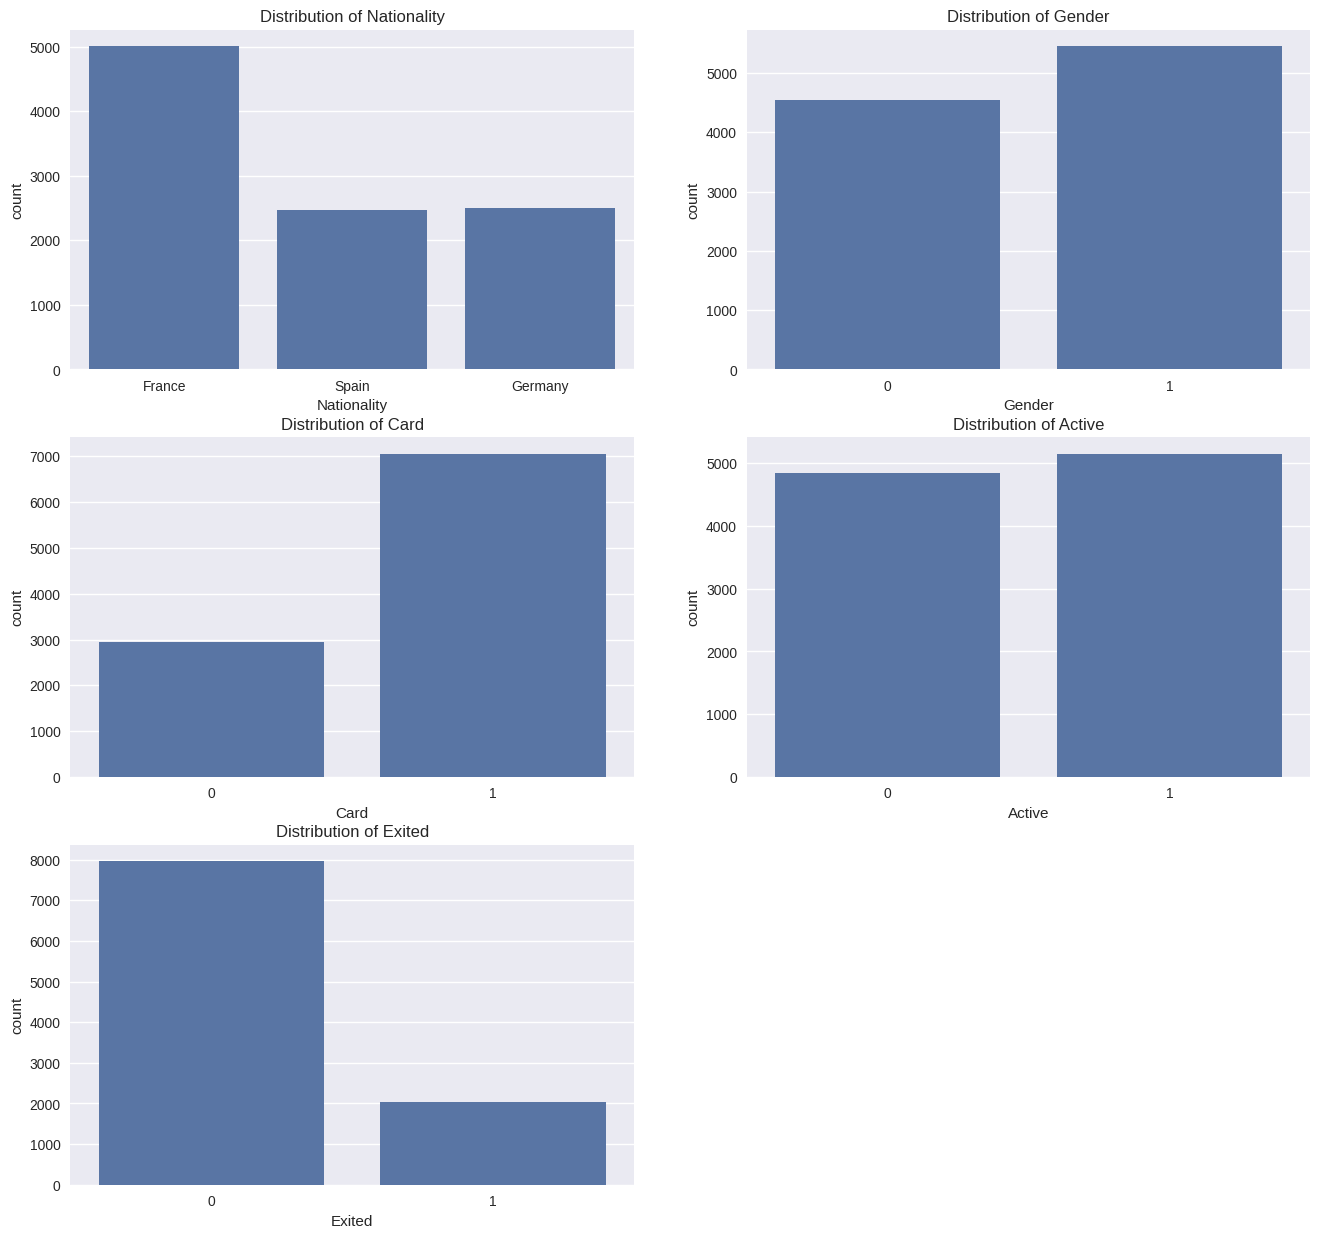

In [41]:
#categorical features
cat= ['Nationality','Gender','Card','Active','Exited']

plt.figure(figsize=(16,15))

for i,col in enumerate(cat):
    plt.subplot(3,2,i +1)
    sns.countplot(df,x=col)
    plt.title(f'Distribution of {col}')

plt.show()

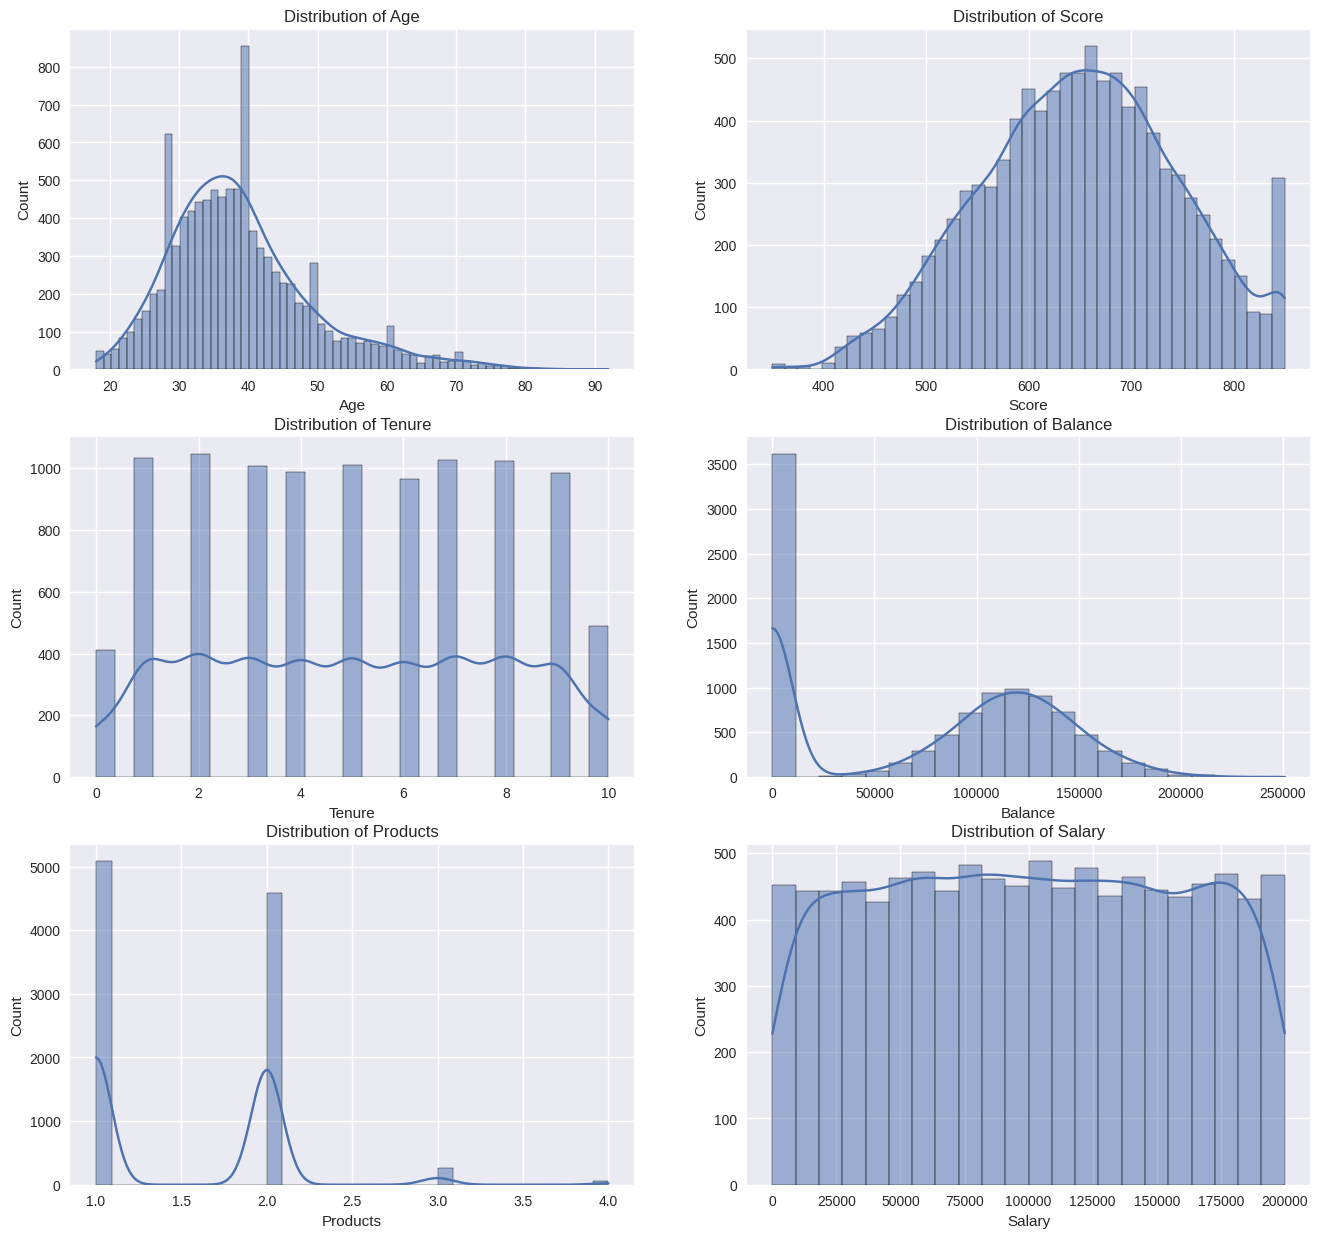

In [12]:
#numerical features
num= ['Age','Score','Tenure','Balance','Products','Salary']

plt.figure(figsize=(16,15))

for i,col in enumerate(num):
    plt.subplot(3,2,i +1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')

plt.show()

1. <h4> How many customers churned by age group?

/tmp/ipykernel_36003/3825421981.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age= age.groupby('Age_bins')['Exited'].value_counts().reset_index()


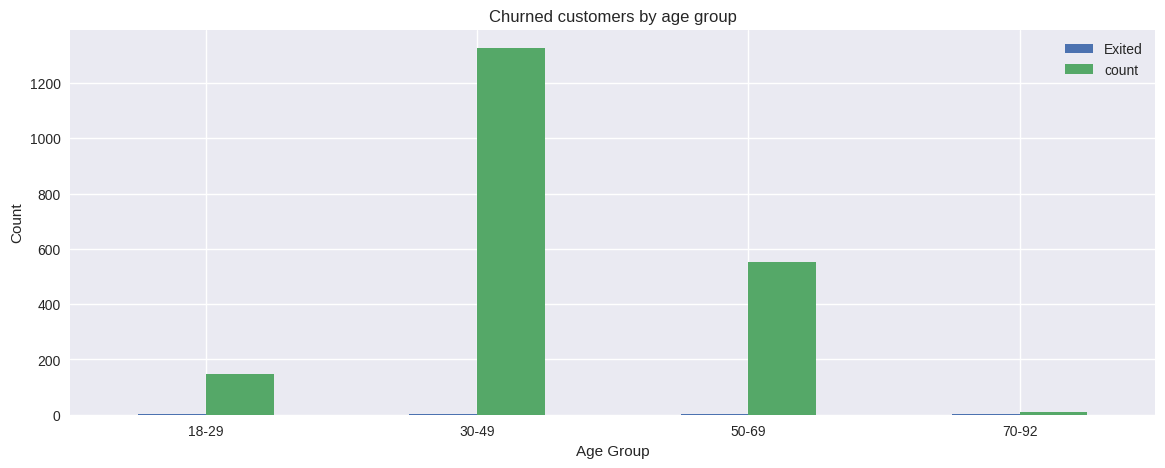

In [13]:
age= df[['Age_bins','Exited']]

age= age[(age['Exited']==1)]
age= age.groupby('Age_bins')['Exited'].value_counts().reset_index()
age.set_index('Age_bins',inplace=True)
age.plot(kind='bar',figsize=(14,5))
plt.title('Churned customers by age group')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.xticks(rotation= 0, ha='center')

plt.show()

2. <h4> What is the average salary by gender?

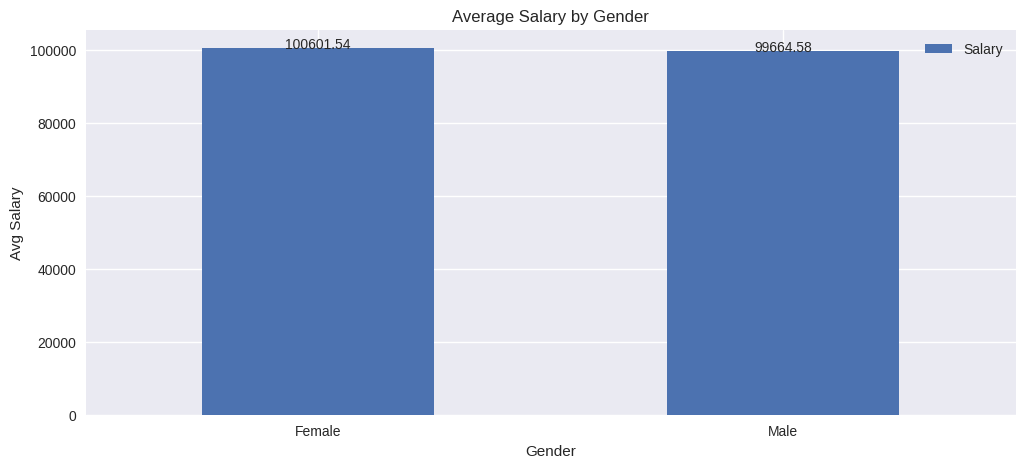

In [14]:
salary= df[['Gender','Salary']]

salary =salary.groupby('Gender')['Salary'].mean().reset_index()
salary.set_index('Gender',inplace= True)
salary= round(salary,2)
salary.plot(kind='bar',figsize=(12,5))
plt.title('Average Salary by Gender')
plt.ylabel('Avg Salary')
plt.xticks(rotation=0, ha='center')
plt.legend(loc='upper right')

for i,v in enumerate(salary['Salary']):
    plt.text(i,v +0.5 , str(v),ha='center')

plt.show()

3. <h4> What is the total of customers?

In [15]:
Total_customers= len(df)
Total_customers

10000

4. <h4> What is the churn distribution by Products & Gender?

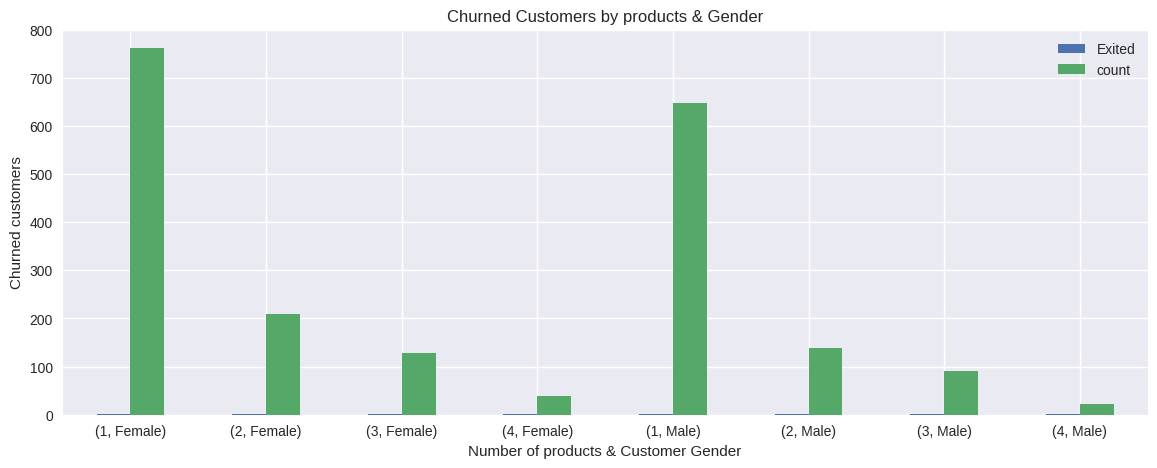

In [16]:
product= df[['Exited','Products','Gender']]

prod= product[(product['Exited']==1)]
prod= prod.groupby(['Exited','Gender'])['Products'].value_counts().reset_index()
prod.set_index(['Products','Gender'],inplace=True)
prod.plot(kind='bar',figsize=(14,5))
plt.title('Churned Customers by products & Gender')
plt.xlabel('Number of products & Customer Gender')
plt.ylabel('Churned customers')
plt.xticks(rotation=0,ha='center')

plt.show()

5. <h4> What is the churn distribution by card?

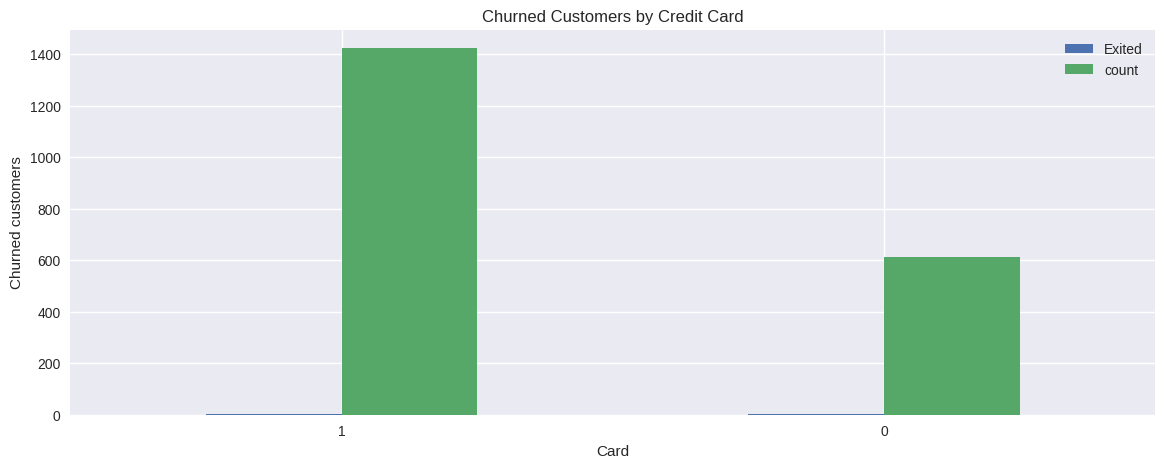

In [17]:
card= df[['Exited','Card']]
card= card[(card['Exited']==1)]
card= card.groupby('Exited')['Card'].value_counts().reset_index()
card.set_index('Card',inplace =True)
card.plot(kind='bar',figsize=(14,5))
plt.title('Churned Customers by Credit Card')
plt.xlabel('Card')
plt.ylabel('Churned customers')
plt.xticks(rotation=0,ha='center')

plt.show()

6. <h4> What is the average credit score for churned customers?

In [18]:
score= df[['Score','Exited']]
score= score[(score['Exited']==1)]
score= score.groupby('Exited')['Score'].mean()
round(score)

,Score
Exited,
1,645.0


7. <h4> What is the churn distribution by tenure?

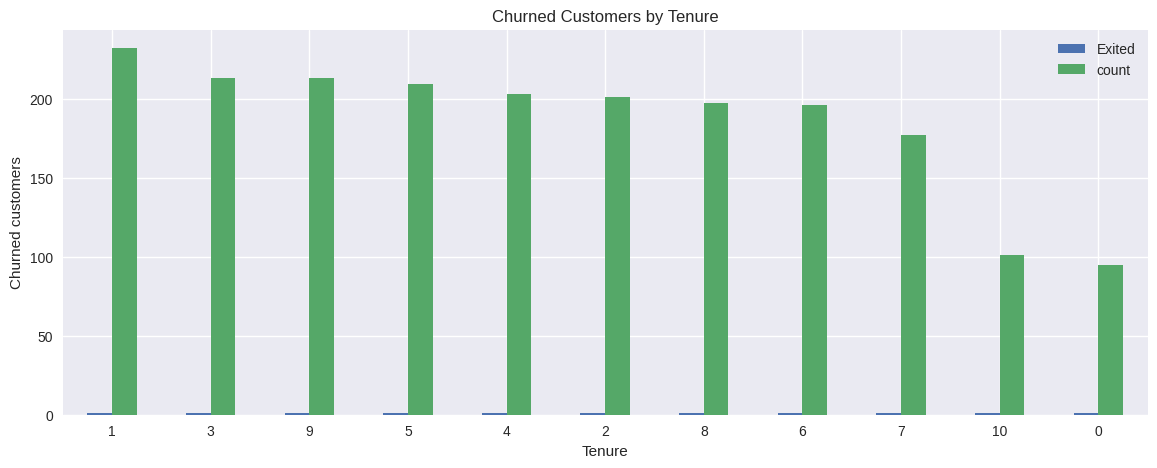

In [19]:
ten= df[['Exited','Tenure']]
ten= ten[(ten['Exited']==1)]
ten= ten.groupby('Exited')['Tenure'].value_counts().reset_index()
ten.set_index('Tenure',inplace =True)
ten= ten.sort_values(by='Exited',ascending=False)
ten.plot(kind='bar',figsize=(14,5))
plt.title('Churned Customers by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Churned customers')
plt.xticks(rotation=0,ha='center')

plt.show()

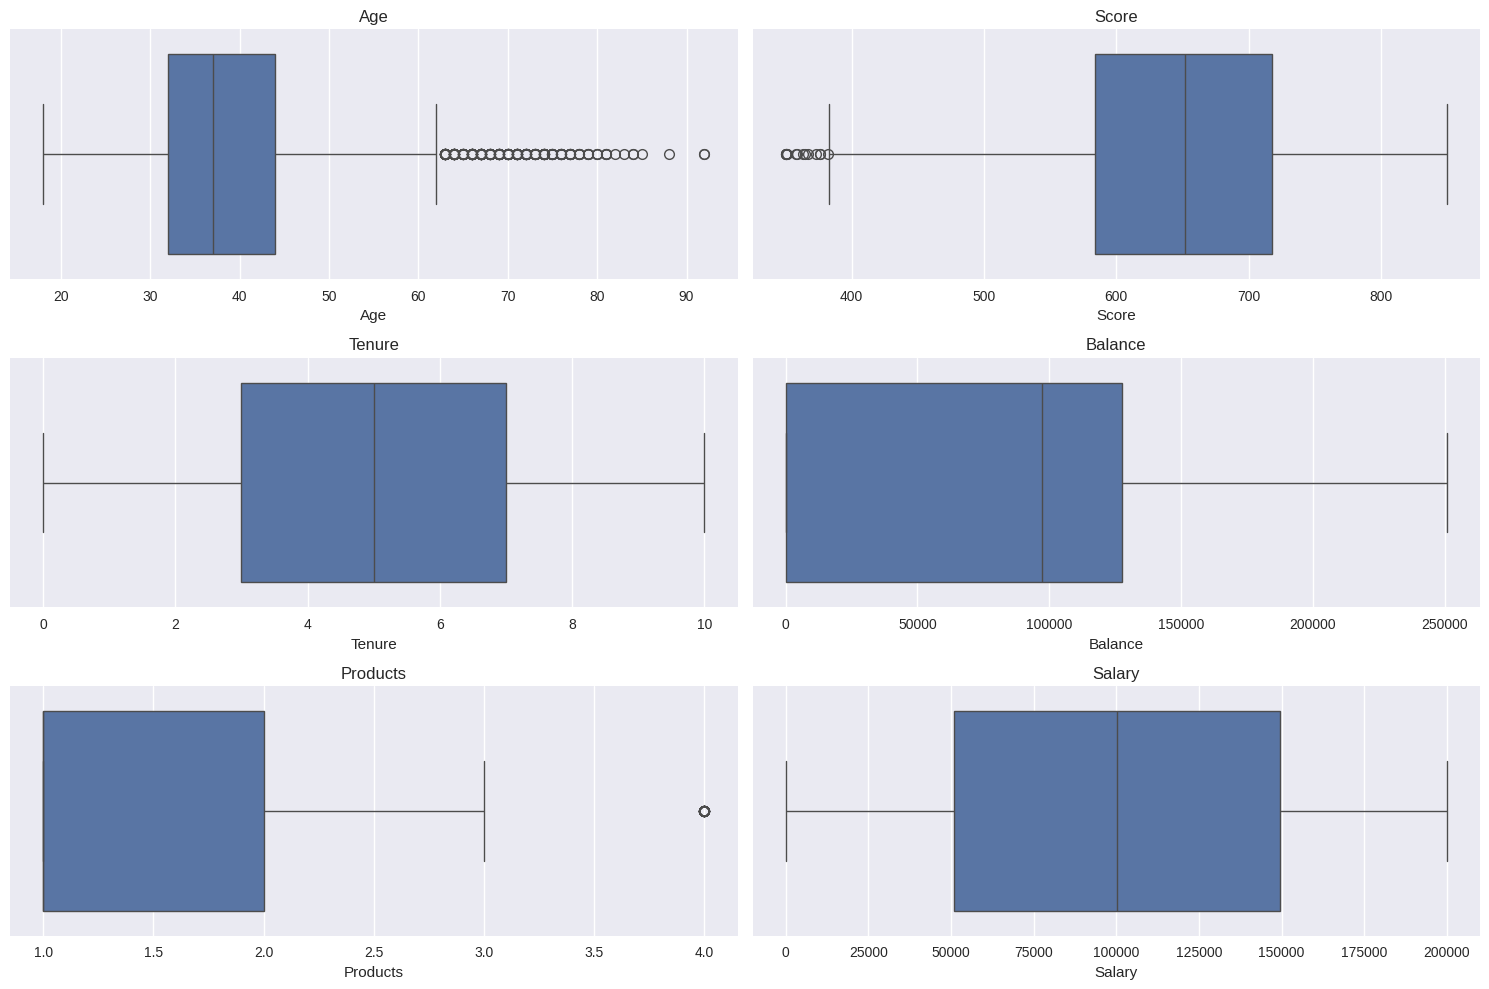

In [20]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num):
    plt.subplot(3,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Correlation Analysis**

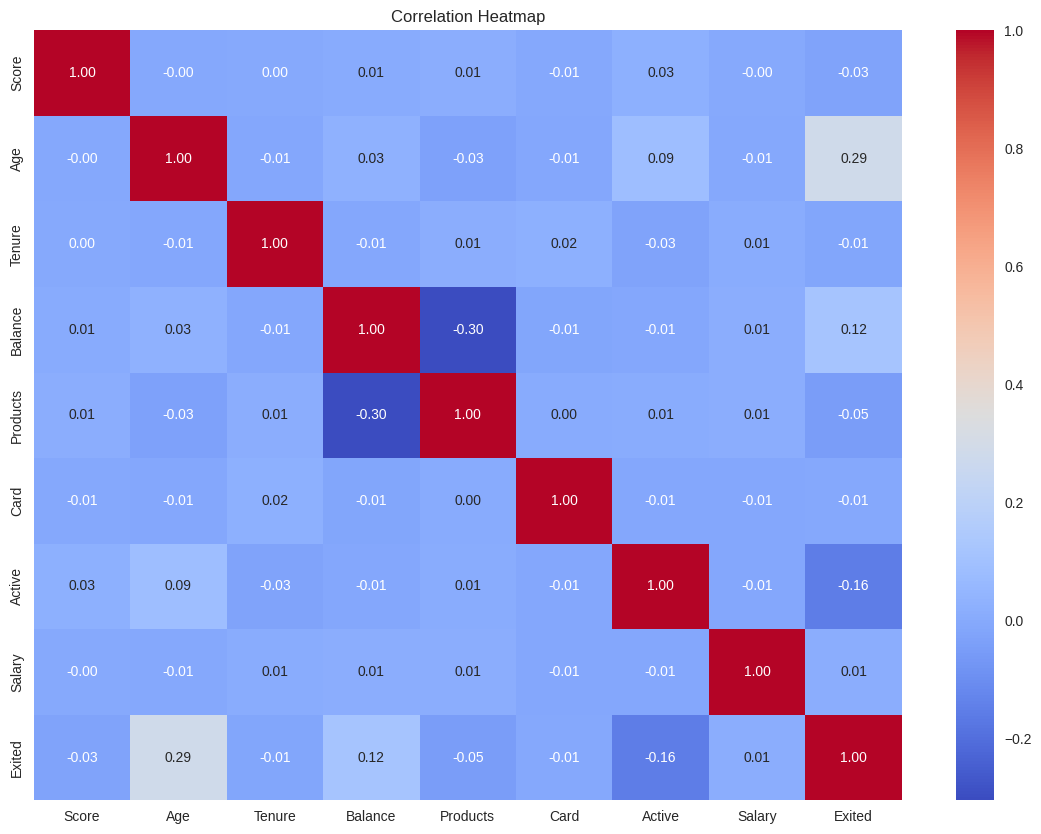

In [21]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

DATA PREPROCESSING

In [22]:
#Encode categorical features
le= LabelEncoder()

cat= ['Gender','Card','Active','Exited']

for i in (cat):
    df[i]= le.fit_transform(df[i])

In [23]:
#split the data into features & target variable
X= df.drop(columns=['Exited','Age_bins'],axis=1)

y=df['Exited']

SPLIT THE DATASET INTO TRAINING AND TESTING SETS

In [24]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
cat_cols = ['Nationality']
num_cols = ['Score', 'Age', 'Tenure', 'Balance', 'Products', 'Salary']

# Preprocessor
preprocess = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(), cat_cols),
    ("num", StandardScaler(), num_cols)
], remainder='passthrough')

In [25]:
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBooster": XGBClassifier()
}

In [26]:

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)

In [27]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [28]:
from imblearn.pipeline import Pipeline
rows = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )

    rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC AUC": scores["test_roc_auc"].mean()
    })

In [29]:
comparison = pd.DataFrame(rows)

comparison = comparison.sort_values(
    by="CV F1",
    ascending=False
)

print(comparison)

                Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
2    GradientBoosting     0.840429      0.609913   0.604471  0.606625   
1        RandomForest     0.842857      0.635500   0.537873  0.582191   
3           XGBooster     0.839143      0.629800   0.514717  0.565930   
0  LogisticRegression     0.690286      0.359472   0.665506  0.466705   

   CV ROC AUC  
2    0.850254  
1    0.843521  
3    0.828418  
0    0.744257  


In [30]:
# Select Best Model

best_model_name = comparison.iloc[0]["Model"]

print("Best Model is:", best_model_name)

Best Model is: GradientBoosting


In [31]:
gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4, 5]
}

grid = GridSearchCV(
    estimator=gb_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
0.6090416871516627


In [32]:
print(grid.best_params_)
print(grid.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
0.6090416871516627


In [33]:
gb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ))
    ]
)

gb_best.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OrdinalEncoder(),
                                                  ['Nationality']),
                                                 ('num', StandardScaler(),
                                                  ['Score', 'Age', 'Tenure',
                                                   'Balance', 'Products',
                                                   'Salary'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=5,
                                            random_state=42))])

In [34]:
train_final_pred = gb_best.predict(X_train)

train_final_f1 = f1_score(y_train, train_final_pred)
train_final_acc = accuracy_score(y_train, train_final_pred)
train_final_precision = precision_score(y_train, train_final_pred)
train_final_recall = recall_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned GradientBoosting) Train Performance ===")
print(f"F1 Score : {train_final_f1:.3f}")
print(f"Accuracy : {train_final_acc:.3f}")
print(f"Precision: {train_final_precision:.3f}")
print(f"Recall   : {train_final_recall:.3f}")


=== FINAL MODEL (Tuned GradientBoosting) Train Performance ===
F1 Score : 0.660
Accuracy : 0.860
Precision: 0.651
Recall   : 0.670


In [35]:
test_final_pred = gb_best.predict(X_test)

test_final_f1 = f1_score(y_test, test_final_pred)
test_final_acc = accuracy_score(y_test, test_final_pred)
test_final_precision = precision_score(y_test, test_final_pred)
test_final_recall = recall_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned GradientBoosting) Test Performance ===")
print(f"F1 Score : {test_final_f1:.3f}")
print(f"Accuracy : {test_final_acc:.3f}")
print(f"Precision: {test_final_precision:.3f}")
print(f"Recall   : {test_final_recall:.3f}")


=== FINAL MODEL (Tuned GradientBoosting) Test Performance ===
F1 Score : 0.630
Accuracy : 0.845
Precision: 0.613
Recall   : 0.648


             Feature  Importance
2           num__Age    0.400797
5      num__Products    0.196488
9  remainder__Active    0.118697
0   cat__Nationality    0.085768
7  remainder__Gender    0.073898
4       num__Balance    0.057078
8    remainder__Card    0.025868
3        num__Tenure    0.018530
6        num__Salary    0.013354
1         num__Score    0.009522


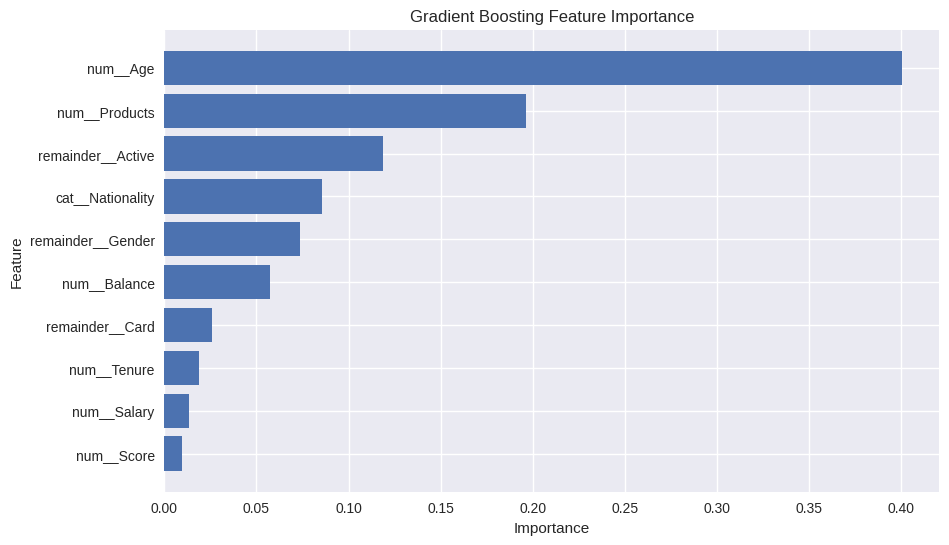

In [36]:
#  Get trained model from pipeline
model = gb_best.named_steps["model"]

#  Feature importance values
importances = model.feature_importances_

#  Feature names from preprocessing
feature_names = gb_best.named_steps["preprocess"].get_feature_names_out()

#  Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

#  Sort by importance
feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feat_imp)

#  Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

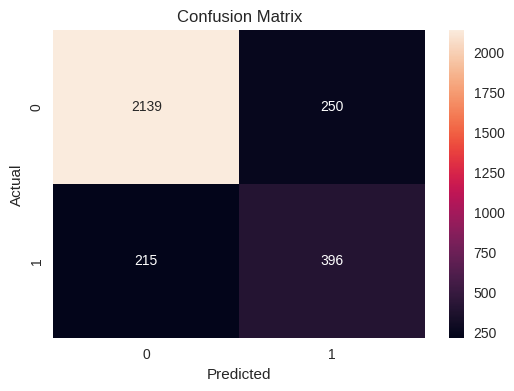

In [37]:
  # Confusion Matrix


cm = confusion_matrix(y_test, test_final_pred )

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

ROC-AUC Score: 0.875684996495805


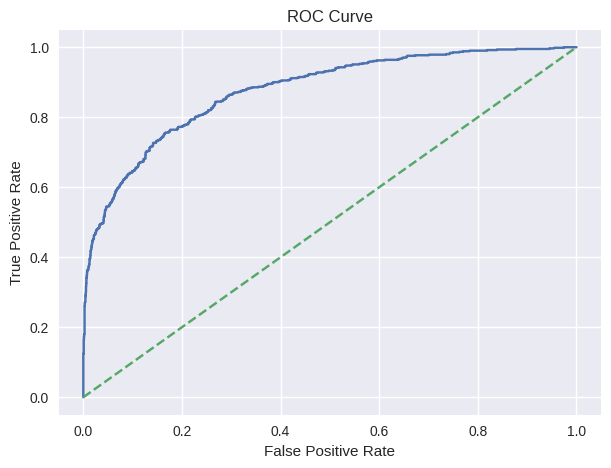

In [38]:
# ROC Curve

y_prob = gb_best.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()# ROC Curve



In [39]:


def predict_churn(
    model,
    score,
    nationality,
    gender,
    age,
    tenure,
    balance,
    products,
    card,
    active,
    salary
):
    """
    Predict customer churn.

    Returns:
        0 -> Customer stays
        1 -> Customer churns
    """
    if gender.lower()=='male':
      gender = 1
    elif gender.lower()=='female':
      gender = 0
    if card.lower() =='yes':
      card = 1
    elif card.lower()=='no':
      card = 0
    if active.lower()=="yes":
      active = 1
    elif active.lower()=='no':
      active = 0

    new_customer = pd.DataFrame([{
        "Score": score,
        "Nationality": nationality,
        "Gender": gender,
        "Age": age,
        "Tenure": tenure,
        "Balance": balance,
        "Products": products,
        "Card": card,
        "Active": active,
        "Salary": salary
    }])



    prediction = model.predict(new_customer)[0]

    return prediction

In [40]:
prediction = predict_churn(
    gb_best,
    score=650,
    nationality="France",
    gender="Male",
    age=45,
    tenure=5,
    balance=50000,
    products=2,
    card="Yes",
    active="Yes",
    salary=60000
)

print("Churn" if prediction == 1 else "Stay")

Stay
